<a href="https://colab.research.google.com/github/ajinfajrian/DataScience_240401020100_Fajrian/blob/master/Pertemuan10_Fajrian_Ichlasul_240401020100.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nama:** Fajrian Ichlasul Maruto \
**NIM:** 240401020100 \
**Kelas:** IF401 \
**Mata Kuliah:** Data Science \
**Pertemuan 10:** Algoritma Klasifikasi - Random Forest & Imbalanced Dataset

### Import Library & Load Dataset Publik

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Memuat dataset Telco Customer Churn dari raw GitHub link
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("Dimensi dataset:", df.shape)
print("\nProporsi Target Churn:")
print(df['Churn'].value_counts(normalize=True) * 100)

df.head()

Dimensi dataset: (7043, 21)

Proporsi Target Churn:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Data Preprocessing (Pembersihan & Encoding)

In [6]:
# 1. Menghapus kolom customerID karena tidak relevan untuk prediksi
df = df.drop('customerID', axis=1)

# 2. Mengubah kolom TotalCharges menjadi numerik (ada spasi kosong yang akan diubah menjadi NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 3. Menghapus baris yang memiliki nilai NaN pada TotalCharges (hanya 11 baris)
df = df.dropna()

# 4. Mengubah target 'Churn' menjadi biner (1 untuk Yes, 0 untuk No)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 5. One-Hot Encoding untuk kolom kategorikal lainnya
X = pd.get_dummies(df.drop('Churn', axis=1), drop_first=True)
y = df['Churn']

# Stratified Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Jumlah data latih: {len(X_train)}")
print(f"Jumlah data uji: {len(X_test)}")

Jumlah data latih: 5625
Jumlah data uji: 1407


### Model 1 - Random Forest (Default / Tanpa Penanganan Imbalanced)

=== Evaluasi Random Forest (Default) ===
Accuracy : 0.7896
Precision: 0.6258
Recall   : 0.5187
F1-Score : 0.5673



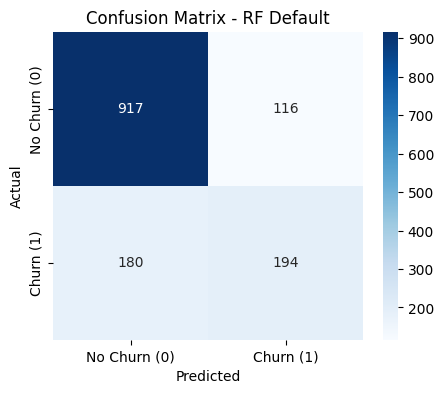

In [7]:
# Inisialisasi dan Latih Model Default
rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train, y_train)

# Prediksi
y_pred_def = rf_default.predict(X_test)

# Evaluasi
print("=== Evaluasi Random Forest (Default) ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_def):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_def):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_def):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_def):.4f}\n")

# Visualisasi Confusion Matrix
cm_def = confusion_matrix(y_test, y_pred_def)
plt.figure(figsize=(5,4))
sns.heatmap(cm_def, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn (0)', 'Churn (1)'], yticklabels=['No Churn (0)', 'Churn (1)'])
plt.title('Confusion Matrix - RF Default')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Model 2 - Random Forest (Dengan Penanganan Imbalanced: Class Weight)

=== Evaluasi Random Forest (Balanced) ===
Accuracy : 0.7889
Precision: 0.6323
Recall   : 0.4920
F1-Score : 0.5534



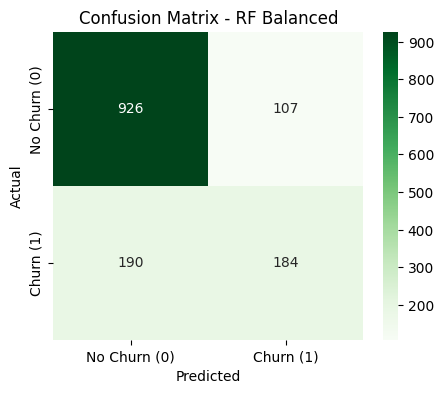

In [8]:
# Inisialisasi Model dengan parameter class_weight='balanced'
rf_balanced = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_balanced.fit(X_train, y_train)

# Prediksi
y_pred_bal = rf_balanced.predict(X_test)

# Evaluasi
print("=== Evaluasi Random Forest (Balanced) ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_bal):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_bal):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_bal):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_bal):.4f}\n")

# Visualisasi Confusion Matrix
cm_bal = confusion_matrix(y_test, y_pred_bal)
plt.figure(figsize=(5,4))
sns.heatmap(cm_bal, annot=True, fmt='d', cmap='Greens', xticklabels=['No Churn (0)', 'Churn (1)'], yticklabels=['No Churn (0)', 'Churn (1)'])
plt.title('Confusion Matrix - RF Balanced')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Kesimpulan

### Kesimpulan Pertemuan 10
* **Data & Problem:** Kita menggunakan dataset Telco Customer Churn yang bersifat tidak seimbang (*imbalanced*), di mana jumlah pelanggan yang pindah (Churn) jauh lebih sedikit (~26.5%) dibandingkan pelanggan yang menetap.
* **Hasil Evaluasi:** Model Random Forest default menghasilkan nilai akurasi keseluruhan yang terlihat tinggi, namun sangat lemah dalam mendeteksi pelanggan yang benar-benar akan Churn (nilai *Recall* rendah).
* **Solusi Penanganan:** Dengan menambahkan parameter `class_weight='balanced'`, model memberikan penalti yang lebih besar pada kelas minoritas. Hasilnya, metrik **Recall meningkat secara signifikan**, yang berarti model jauh lebih baik dalam menangkap pelanggan berisiko tinggi untuk tindakan retensi.